1. Import Library

In [31]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [32]:
# =====================================================
# PATH DATASET
# =====================================================

dataset_path = "../preprocessed_dataset/Berminyak"

In [33]:
# =====================================================
# FACE DETECTOR
# =====================================================

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    "haarcascade_frontalface_default.xml"
)

In [34]:
# =====================================================
# AMBIL SEMUA FILE GAMBAR
# =====================================================

image_files = [
    f for f in os.listdir(dataset_path)
    if f.lower().endswith(('.png', '.jpg', '.jpeg'))
]

print("Jumlah gambar :", len(image_files))

Jumlah gambar : 10


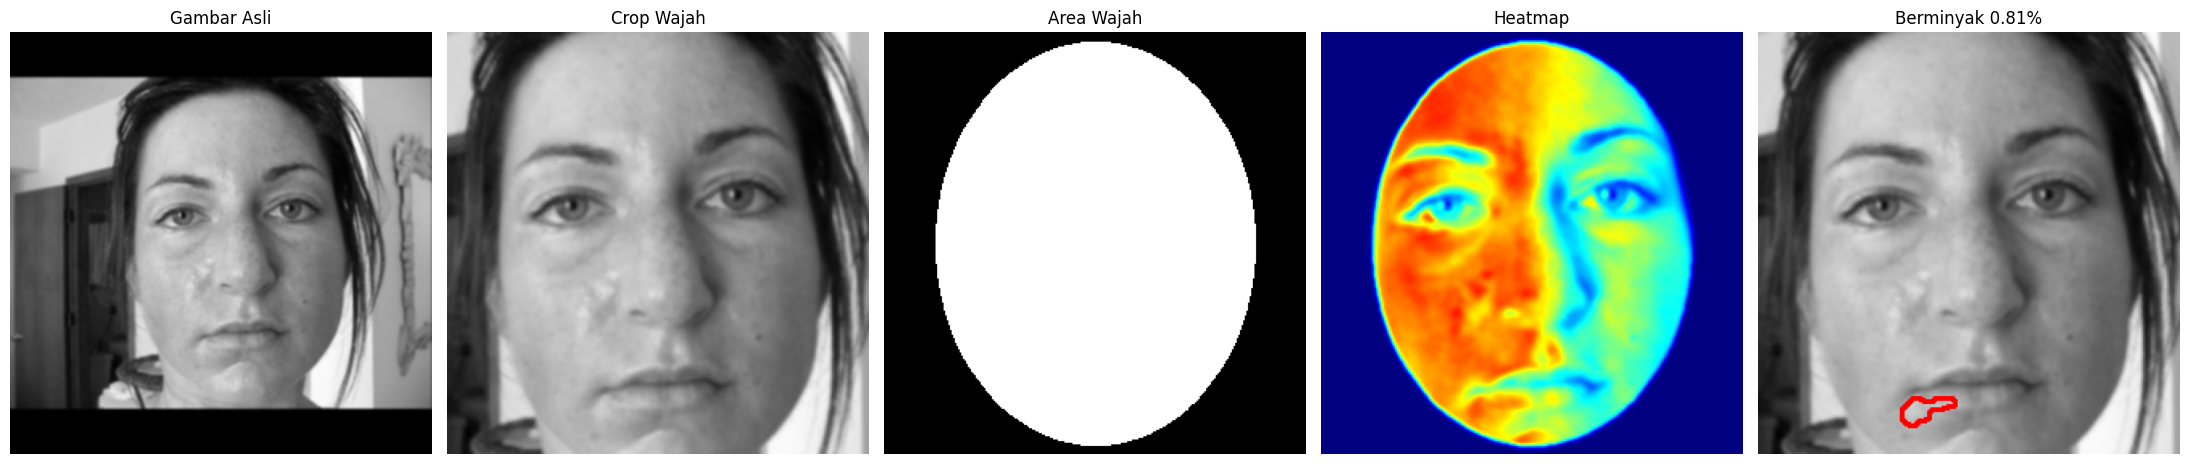

File : 1.jpg
Threshold : 178.98
Persentase berminyak : 0.81%


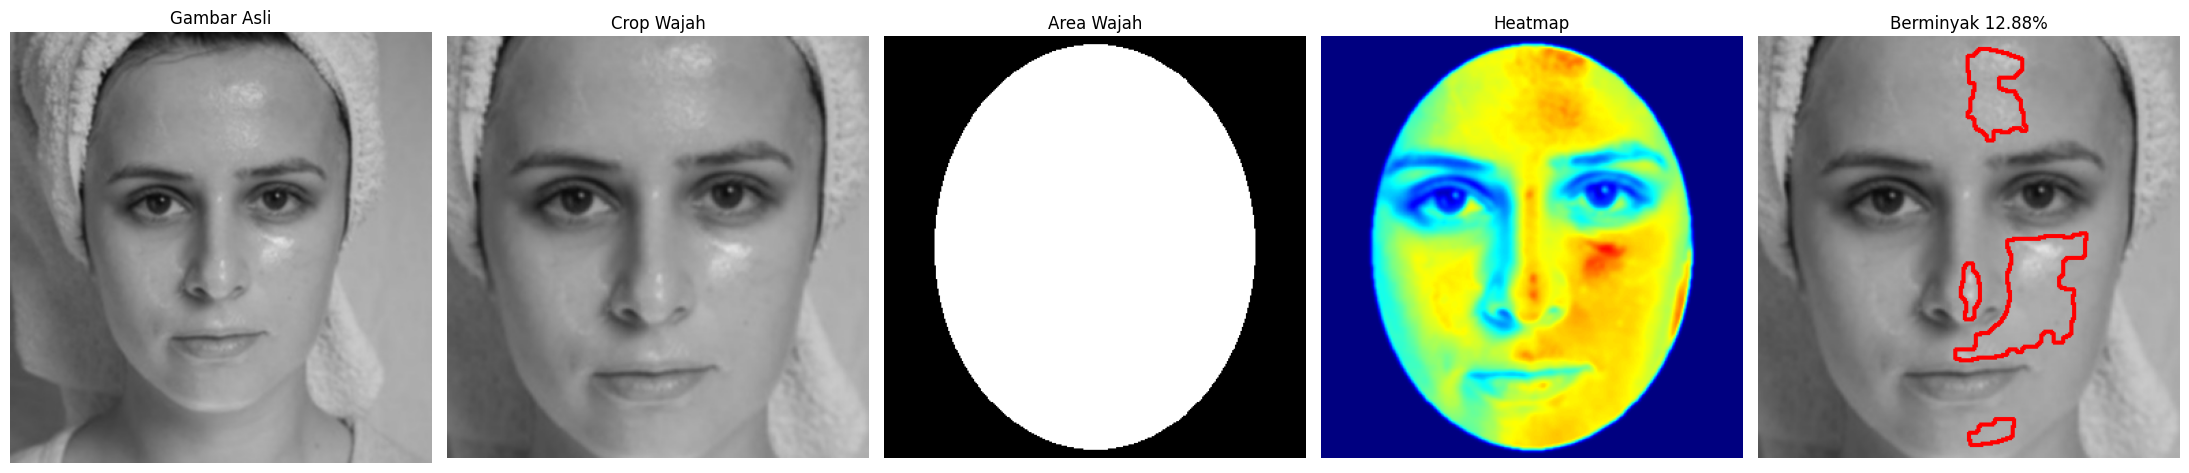

File : 10.jpeg
Threshold : 167.80
Persentase berminyak : 12.88%
Wajah tidak ditemukan: 2.jpg


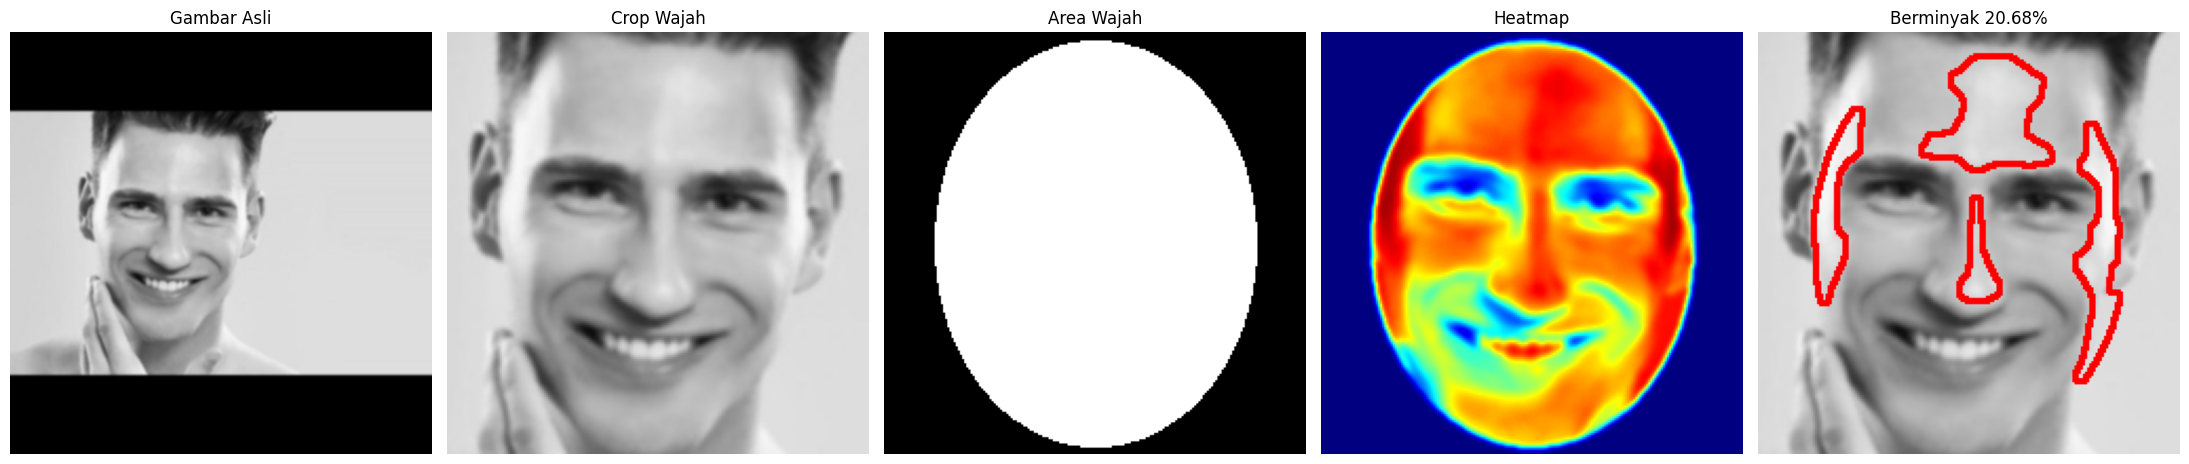

File : 3.jpg
Threshold : 200.40
Persentase berminyak : 20.68%


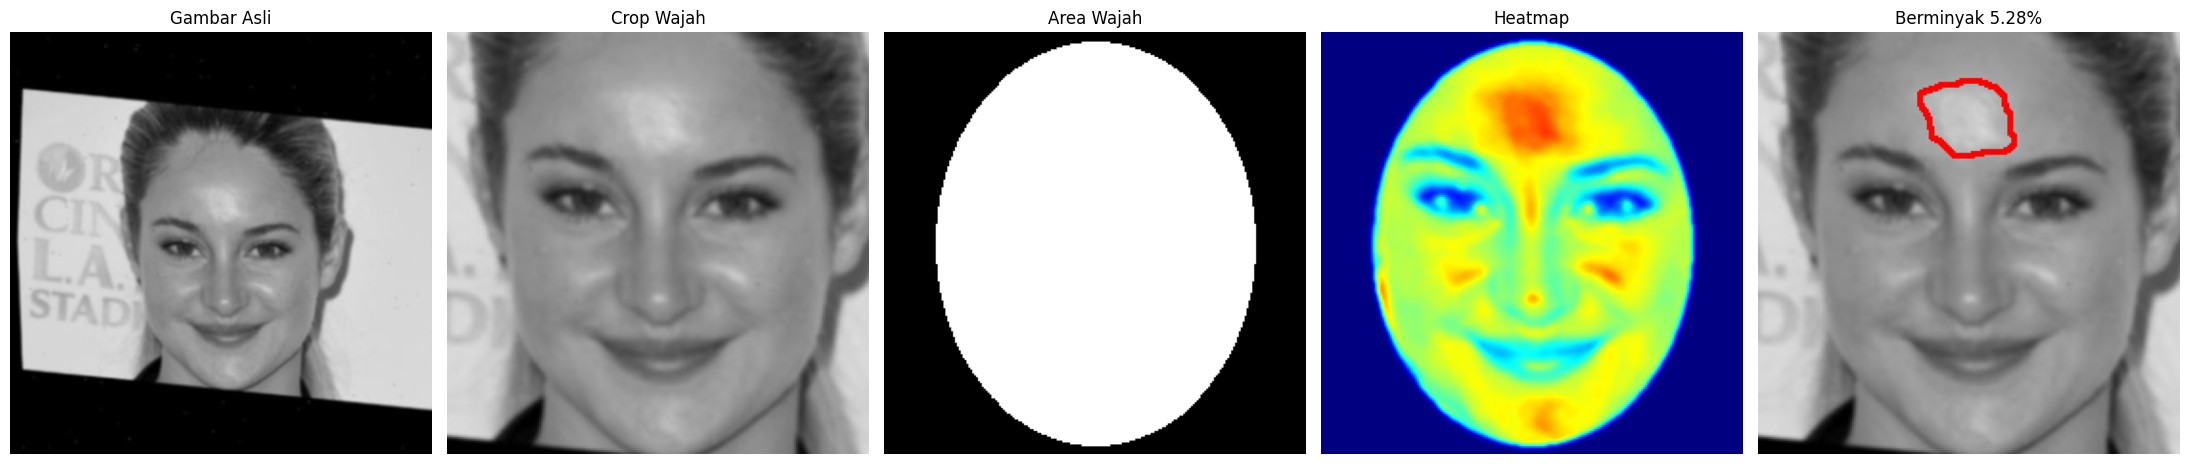

File : 4.jpg
Threshold : 169.11
Persentase berminyak : 5.28%


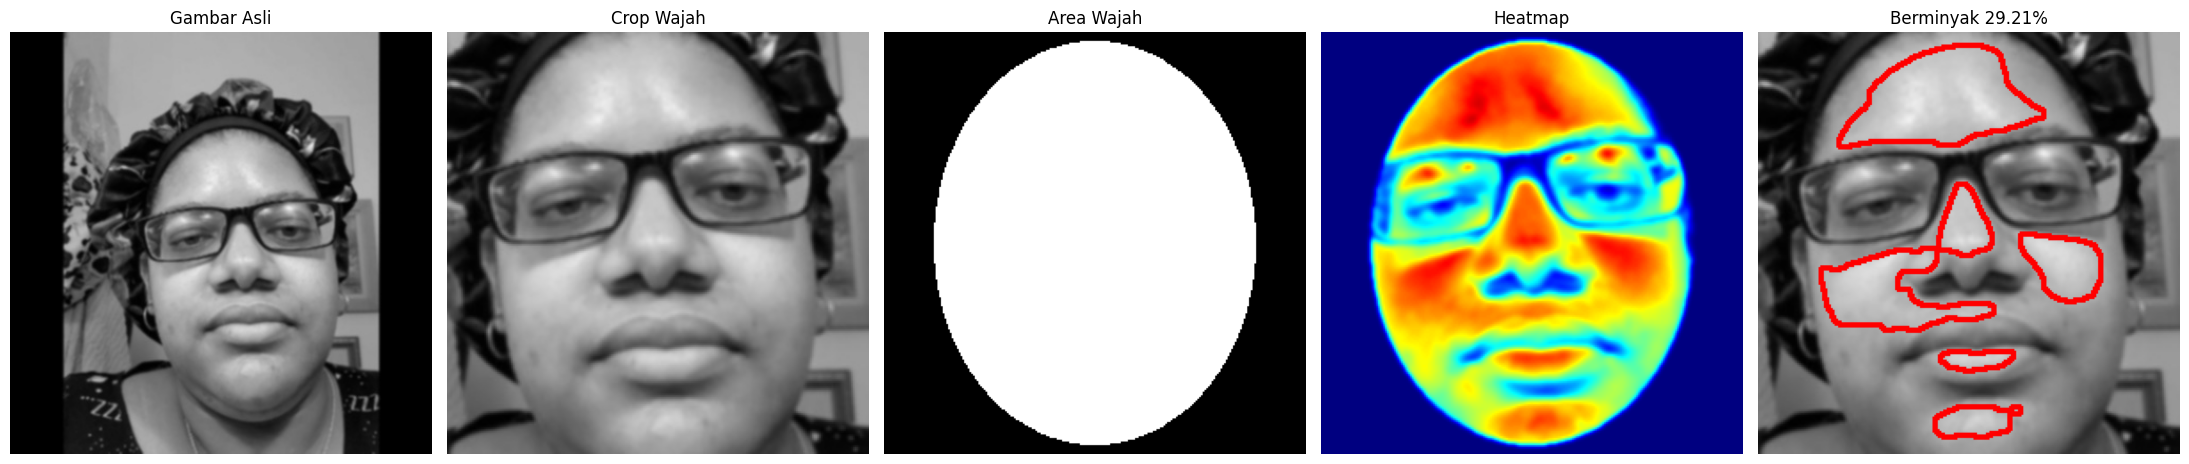

File : 5.jpg
Threshold : 172.78
Persentase berminyak : 29.21%


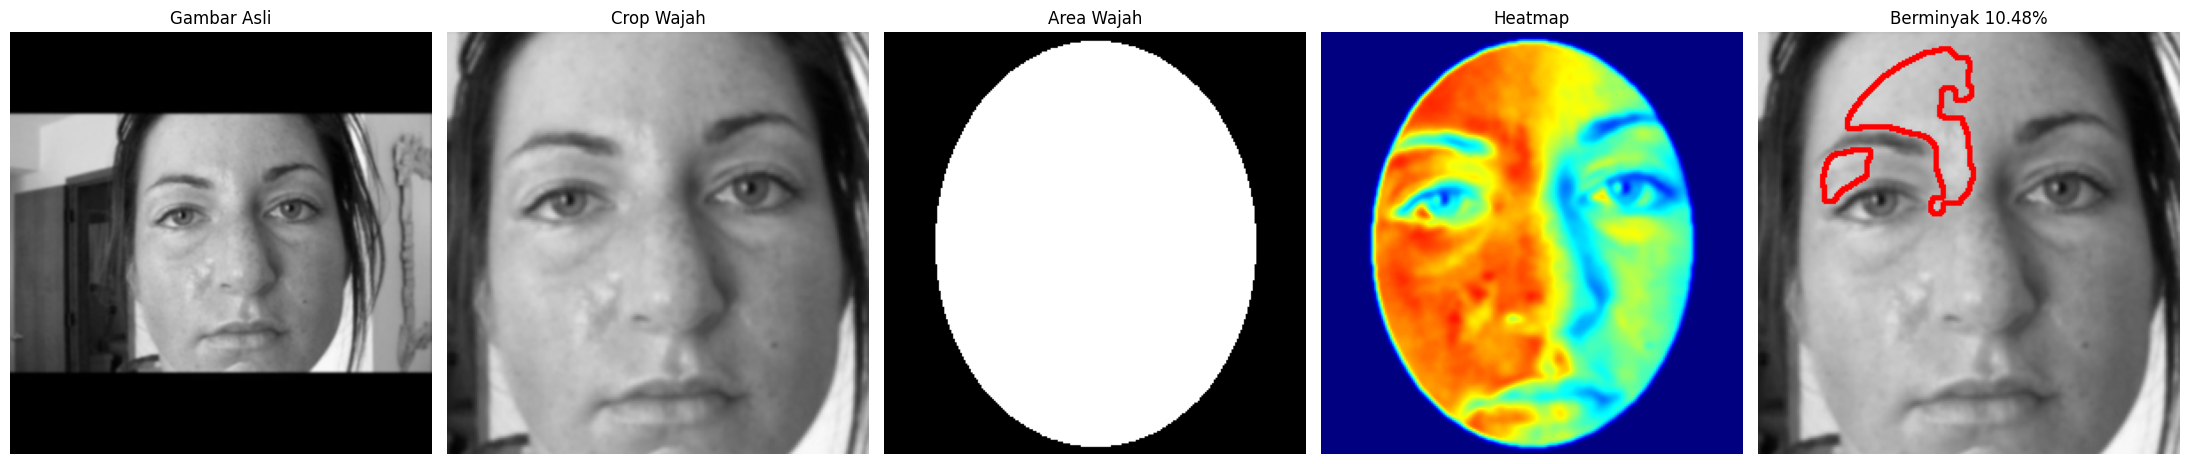

File : 6.jpg
Threshold : 181.27
Persentase berminyak : 10.48%


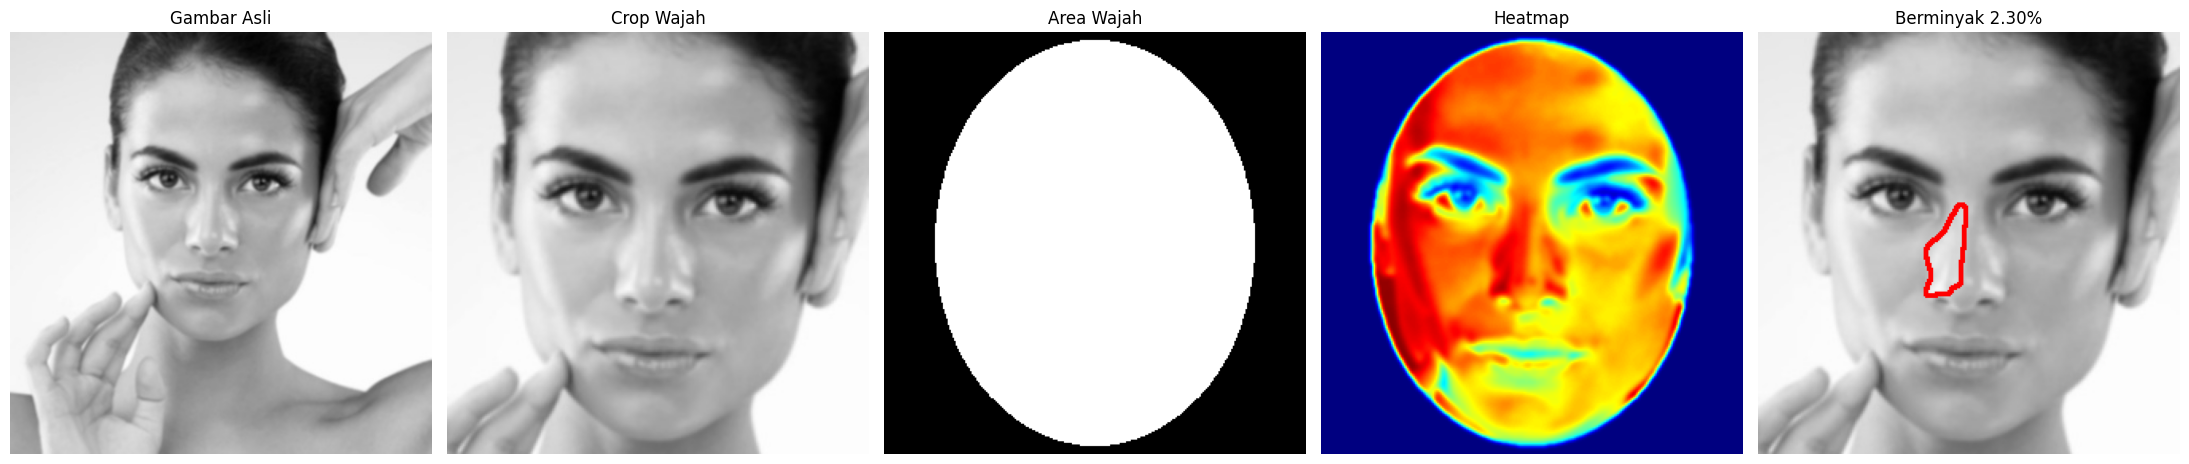

File : 7.jpg
Threshold : 203.24
Persentase berminyak : 2.30%


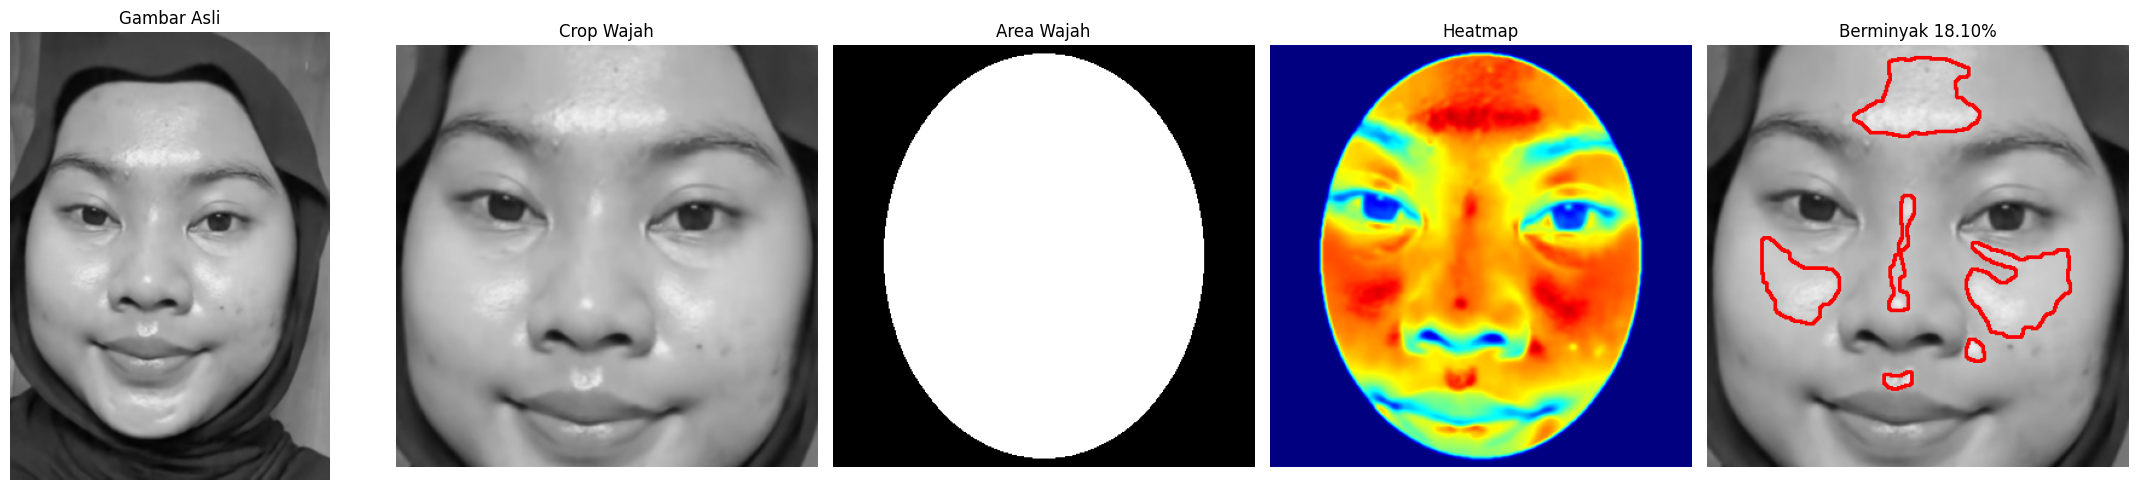

File : 8.jpeg
Threshold : 196.84
Persentase berminyak : 18.10%


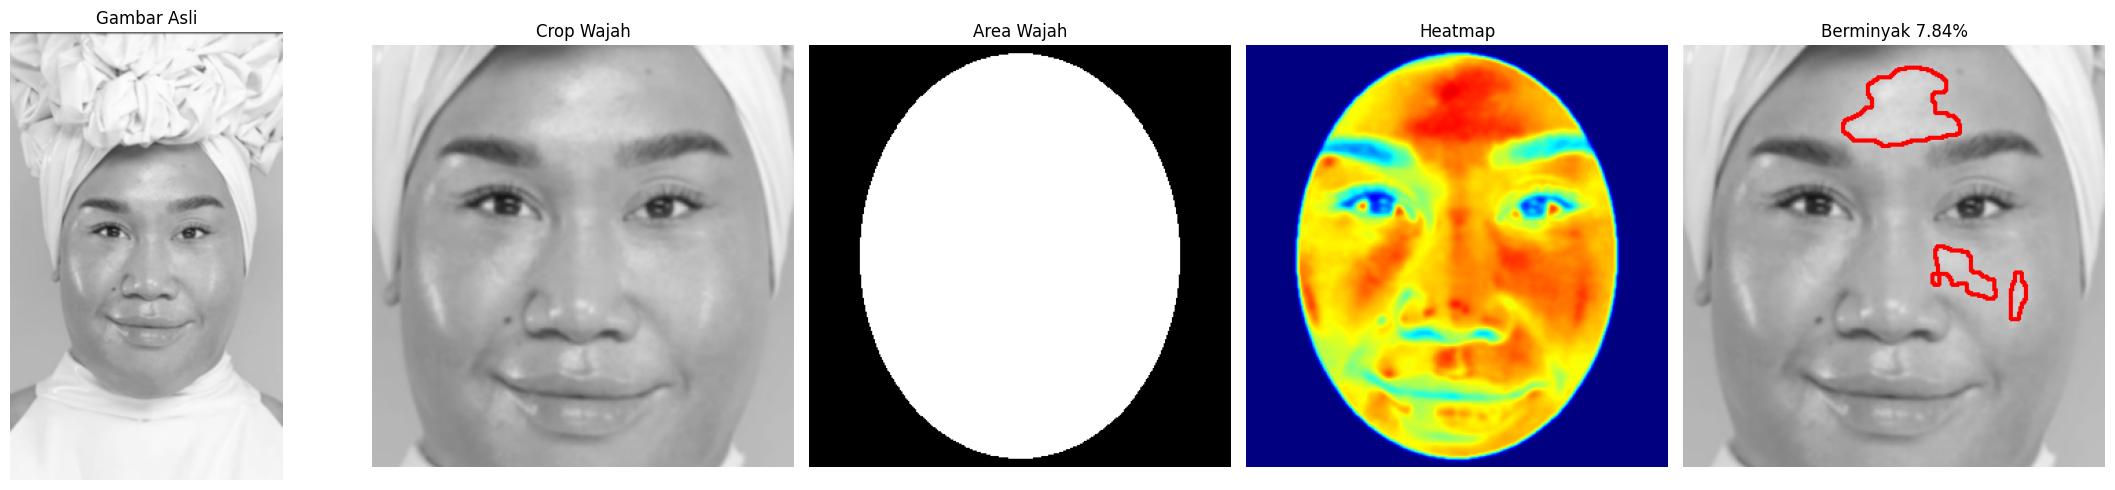

File : 9.jpeg
Threshold : 196.46
Persentase berminyak : 7.84%


In [40]:
# =====================================================
# LOOP SEMUA GAMBAR
# =====================================================

for file_name in image_files:

    img_path = os.path.join(dataset_path, file_name)

    # =================================================
    # BACA GAMBAR
    # =================================================
    image = cv2.imread(img_path)

    if image is None:
        print(f"Gagal membaca gambar: {file_name}")
        continue

    original = image.copy()

    # =================================================
    # DETEKSI WAJAH
    # =================================================
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(100,100)
    )

    if len(faces) == 0:
        print(f"Wajah tidak ditemukan: {file_name}")
        continue

    # =================================================
    # AMBIL WAJAH PERTAMA
    # =================================================
    (x, y, w, h) = faces[0]

    # =================================================
    # CROP WAJAH
    # =================================================
    face = image[y:y+h, x:x+w]

    # =================================================
    # GRAYSCALE
    # =================================================
    face_gray = cv2.cvtColor(
        face,
        cv2.COLOR_BGR2GRAY
    )

    # =================================================
    # MASK ELLIPSE WAJAH
    # =================================================
    mask = np.zeros_like(face_gray)

    center = (w // 2, h // 2)

    axes = (
        int(w * 0.38),
        int(h * 0.48)
    )

    cv2.ellipse(
        mask,
        center,
        axes,
        0,
        0,
        360,
        255,
        -1
    )

    # =================================================
    # AREA WAJAH SAJA
    # =================================================
    face_only = cv2.bitwise_and(
        face_gray,
        face_gray,
        mask=mask
    )

    # =================================================
    # SMOOTHING RINGAN
    # =================================================
    blur = cv2.GaussianBlur(
        face_only,
        (7,7),
        0
    )

    # =================================================
    # HEATMAP
    # =================================================
    heatmap = cv2.applyColorMap(
        blur,
        cv2.COLORMAP_JET
    )

    # =================================================
    # THRESHOLD DINAMIS
    # =================================================
    mean_brightness = np.mean(
        blur[mask > 0]
    )

    threshold_value = mean_brightness + 30

    _, oily_mask = cv2.threshold(
        blur,
        threshold_value,
        255,
        cv2.THRESH_BINARY
    )

    # =================================================
    # HANYA AREA WAJAH
    # =================================================
    oily_mask = cv2.bitwise_and(
        oily_mask,
        mask
    )

    # =================================================
    # BERSIHKAN NOISE
    # =================================================
    kernel = np.ones((5,5), np.uint8)

    oily_mask = cv2.morphologyEx(
        oily_mask,
        cv2.MORPH_OPEN,
        kernel
    )

    oily_mask = cv2.morphologyEx(
        oily_mask,
        cv2.MORPH_CLOSE,
        kernel
    )

    # =================================================
    # CARI CONTOUR
    # =================================================
    contours, _ = cv2.findContours(
        oily_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    # =================================================
    # RESULT IMAGE
    # =================================================
    result = cv2.cvtColor(
        face_gray,
        cv2.COLOR_GRAY2BGR
    )

    # =================================================
    # HITUNG AREA BERMINYAK
    # =================================================
    valid_oily_area = 0

    for cnt in contours:

        area = cv2.contourArea(cnt)

        # FILTER CONTOUR
        if 180 < area < 5000:

            valid_oily_area += area

            cv2.drawContours(
                result,
                [cnt],
                -1,
                (0,0,255),
                2
            )

    # =================================================
    # HITUNG PERSENTASE
    # =================================================
    face_pixels = np.sum(mask == 255)

    oily_percentage = (
        valid_oily_area / face_pixels
    ) * 100

    # =================================================
    # DISPLAY
    # =================================================
    fig, ax = plt.subplots(1,5, figsize=(22,5))

    # GAMBAR ASLI
    ax[0].imshow(
        cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    )
    ax[0].set_title("Gambar Asli")
    ax[0].axis("off")

    # CROP WAJAH
    ax[1].imshow(
        cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
    )
    ax[1].set_title("Crop Wajah")
    ax[1].axis("off")

    # MASK WAJAH
    ax[2].imshow(mask, cmap='gray')
    ax[2].set_title("Area Wajah")
    ax[2].axis("off")

    # HEATMAP
    ax[3].imshow(
        cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    )
    ax[3].set_title("Heatmap")
    ax[3].axis("off")

    # HASIL AKHIR
    ax[4].imshow(
        cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
    )
    ax[4].set_title(
        f"Berminyak {oily_percentage:.2f}%"
    )
    ax[4].axis("off")

    plt.tight_layout()
    plt.show()

    # =================================================
    # OUTPUT
    # =================================================
    print("="*60)
    print(f"File : {file_name}")
    print(f"Threshold : {threshold_value:.2f}")
    print(f"Persentase berminyak : {oily_percentage:.2f}%")

In [36]:
# import cv2
# import numpy as np
# import matplotlib.pyplot as plt
# import os

# # =====================================================
# # PATH DATASET
# # =====================================================
# dataset_path = "../preprocessed_dataset/Berminyak"

# # =====================================================
# # FACE DETECTOR
# # =====================================================
# face_cascade = cv2.CascadeClassifier(
#     cv2.data.haarcascades +
#     "haarcascade_frontalface_default.xml"
# )

# # =====================================================
# # AMBIL SEMUA FILE GAMBAR
# # =====================================================
# image_files = [
#     f for f in os.listdir(dataset_path)
#     if f.lower().endswith(('.png', '.jpg', '.jpeg'))
# ]

# # =====================================================
# # LOOP SEMUA GAMBAR
# # =====================================================
# for file_name in image_files:

#     img_path = os.path.join(dataset_path, file_name)

#     # =================================================
#     # BACA GAMBAR
#     # =================================================
#     image = cv2.imread(img_path)

#     if image is None:
#         print(f"Gagal membaca gambar: {file_name}")
#         continue

#     original = image.copy()

#     # =================================================
#     # DETEKSI WAJAH
#     # =================================================
#     gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

#     faces = face_cascade.detectMultiScale(
#         gray,
#         scaleFactor=1.1,
#         minNeighbors=5,
#         minSize=(100,100)
#     )

#     if len(faces) == 0:
#         print(f"Wajah tidak ditemukan: {file_name}")
#         continue

#     # =================================================
#     # AMBIL WAJAH PERTAMA
#     # =================================================
#     (x, y, w, h) = faces[0]

#     # =================================================
#     # CROP WAJAH
#     # =================================================
#     face = image[y:y+h, x:x+w]

#     # =================================================
#     # CONVERT TO GRAYSCALE
#     # =================================================
#     face_gray = cv2.cvtColor(
#         face,
#         cv2.COLOR_BGR2GRAY
#     )

#     # =================================================
#     # CLAHE
#     # MEMPERJELAS AREA KILAP
#     # =================================================
#     clahe = cv2.createCLAHE(
#         clipLimit=2.0,
#         tileGridSize=(8,8)
#     )

#     face_gray = clahe.apply(face_gray)

#     # =================================================
#     # MASK ELLIPSE WAJAH
#     # =================================================
#     mask = np.zeros_like(face_gray)

#     center = (w // 2, h // 2)

#     axes = (
#         int(w * 0.38),
#         int(h * 0.48)
#     )

#     cv2.ellipse(
#         mask,
#         center,
#         axes,
#         0,
#         0,
#         360,
#         255,
#         -1
#     )

#     # =================================================
#     # AMBIL AREA WAJAH SAJA
#     # =================================================
#     face_only = cv2.bitwise_and(
#         face_gray,
#         face_gray,
#         mask=mask
#     )

#     # =================================================
#     # SMOOTHING
#     # =================================================
#     blur = cv2.GaussianBlur(
#         face_only,
#         (11,11),
#         0
#     )

#     # =================================================
#     # HEATMAP
#     # =================================================
#     heatmap = cv2.applyColorMap(
#         blur,
#         cv2.COLORMAP_JET
#     )

#     # =================================================
#     # THRESHOLD DINAMIS
#     # =================================================
#     mean_brightness = np.mean(
#         blur[mask > 0]
#     )

#     threshold_value = mean_brightness + 40

#     _, oily_mask = cv2.threshold(
#         blur,
#         threshold_value,
#         255,
#         cv2.THRESH_BINARY
#     )

#     # =================================================
#     # HANYA AREA WAJAH
#     # =================================================
#     oily_mask = cv2.bitwise_and(
#         oily_mask,
#         mask
#     )

#     # =================================================
#     # BERSIHKAN NOISE
#     # =================================================
#     kernel = np.ones((5,5), np.uint8)

#     oily_mask = cv2.morphologyEx(
#         oily_mask,
#         cv2.MORPH_OPEN,
#         kernel
#     )

#     oily_mask = cv2.morphologyEx(
#         oily_mask,
#         cv2.MORPH_CLOSE,
#         kernel
#     )

#     # =================================================
#     # CARI CONTOUR
#     # =================================================
#     contours, _ = cv2.findContours(
#         oily_mask,
#         cv2.RETR_EXTERNAL,
#         cv2.CHAIN_APPROX_SIMPLE
#     )

#     # =================================================
#     # RESULT IMAGE
#     # =================================================
#     result = cv2.cvtColor(
#         face_gray,
#         cv2.COLOR_GRAY2BGR
#     )

#     # =================================================
#     # GAMBAR AREA BERMINYAK
#     # =================================================
#     for cnt in contours:

#         area = cv2.contourArea(cnt)

#         # FILTER CONTOUR
#         if 80 < area < 4000:

#             cv2.drawContours(
#                 result,
#                 [cnt],
#                 -1,
#                 (0,0,255),
#                 2
#             )

#     # =================================================
#     # HITUNG PERSENTASE BERMINYAK
#     # =================================================
#     oily_pixels = np.sum(oily_mask == 255)

#     face_pixels = np.sum(mask == 255)

#     oily_percentage = (
#         oily_pixels / face_pixels
#     ) * 100

#     # =================================================
#     # DISPLAY
#     # =================================================
#     fig, ax = plt.subplots(1,5, figsize=(22,5))

#     # GAMBAR ASLI
#     ax[0].imshow(
#         cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
#     )
#     ax[0].set_title("Gambar Asli")
#     ax[0].axis("off")

#     # CROP WAJAH
#     ax[1].imshow(
#         cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
#     )
#     ax[1].set_title("Crop Wajah")
#     ax[1].axis("off")

#     # MASK WAJAH
#     ax[2].imshow(mask, cmap='gray')
#     ax[2].set_title("Area Wajah")
#     ax[2].axis("off")

#     # HEATMAP
#     ax[3].imshow(
#         cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
#     )
#     ax[3].set_title("Heatmap")
#     ax[3].axis("off")

#     # HASIL AKHIR
#     ax[4].imshow(
#         cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
#     )
#     ax[4].set_title(
#         f"Berminyak {oily_percentage:.2f}%"
#     )
#     ax[4].axis("off")

#     plt.tight_layout()
#     plt.show()

#     # =================================================
#     # OUTPUT
#     # =================================================
#     print("="*60)
#     print(f"File : {file_name}")
#     print(f"Threshold : {threshold_value:.2f}")
#     print(f"Persentase berminyak : {oily_percentage:.2f}%")